<a href="https://colab.research.google.com/github/anshumandwivediusa/nlp/blob/main/codes/word2vect_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Word2Vec (Skip-gram) from Scratch — PyTorch

Original code by Tae Hwan Jung (@graykode).

This notebook trains a minimal 2-dimensional Skip-gram Word2Vec model on a tiny toy corpus, then plots the learned word embeddings so you can visually see semantically related words (fruits vs. animals) cluster together.

**Run all cells in order** (Runtime → Run all). No file uploads or GPU required — this trains in a few seconds on CPU.

## 1. Setup

Colab already has PyTorch, NumPy, and Matplotlib pre-installed, so no `pip install` is needed. This cell just imports everything.

In [1]:
# code by Tae Hwan Jung @graykode
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

## 2. Batch Sampler

Randomly samples `batch_size` (target, context) skip-gram pairs on each training step. Each target word is converted to a one-hot vector; the context word is left as a plain class index (required by `CrossEntropyLoss`).

In [2]:
def random_batch():
    random_inputs = []
    random_labels = []
    random_index = np.random.choice(range(len(skip_grams)), batch_size, replace=False)

    for i in random_index:
        random_inputs.append(np.eye(voc_size)[skip_grams[i][0]])  # target
        random_labels.append(skip_grams[i][1])  # context word

    return random_inputs, random_labels

## 3. Model Definition

A minimal Skip-gram Word2Vec model: a one-hot input is projected down to a small embedding space by `W`, then projected back up to vocabulary size by `WT` to produce prediction scores over every possible context word. `W`'s weights are the actual word embeddings we care about — `WT` is discarded after training.

In [3]:
class Word2Vec(nn.Module):
    def __init__(self):
        super(Word2Vec, self).__init__()
        # W and WT is not Traspose relationship
        self.W = nn.Linear(voc_size, embedding_size, bias=False) # voc_size > embedding_size Weight
        self.WT = nn.Linear(embedding_size, voc_size, bias=False) # embedding_size > voc_size Weight

    def forward(self, X):
        # X : [batch_size, voc_size]
        hidden_layer = self.W(X) # hidden_layer : [batch_size, embedding_size]
        output_layer = self.WT(hidden_layer) # output_layer : [batch_size, voc_size]
        return output_layer

## 4. Build the Toy Corpus and Skip-gram Pairs

Two thematic groups of sentences (fruits and animals) so the resulting embedding plot clearly shows two separated clusters. A window size of 1 is used: for every word, its immediate left and right neighbor become (target, context) training pairs.

In [4]:
batch_size = 2 # mini-batch size
embedding_size = 2 # embedding size

sentences = ["apple banana fruit", "banana orange fruit", "orange banana fruit",
             "dog cat animal", "cat monkey animal", "monkey dog animal"]

word_sequence = " ".join(sentences).split()
word_list = " ".join(sentences).split()
word_list = list(set(word_list))
word_dict = {w: i for i, w in enumerate(word_list)}
voc_size = len(word_list)

# Make skip gram of one size window
skip_grams = []
for i in range(1, len(word_sequence) - 1):
    target = word_dict[word_sequence[i]]
    context = [word_dict[word_sequence[i - 1]], word_dict[word_sequence[i + 1]]]
    for w in context:
        skip_grams.append([target, w])

print(f"Vocabulary size: {voc_size}")
print(f"Number of skip-gram pairs: {len(skip_grams)}")

Vocabulary size: 8
Number of skip-gram pairs: 32


## 5. Train the Model

Trains for 5000 epochs using Adam and cross-entropy loss, printing the loss every 1000 epochs so you can watch it converge.

In [5]:
model = Word2Vec()

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training
for epoch in range(5000):
    input_batch, target_batch = random_batch()
    input_batch = torch.Tensor(input_batch)
    target_batch = torch.LongTensor(target_batch)

    optimizer.zero_grad()
    output = model(input_batch)

    # output : [batch_size, voc_size], target_batch : [batch_size] (LongTensor, not one-hot)
    loss = criterion(output, target_batch)
    if (epoch + 1) % 1000 == 0:
        print('Epoch:', '%04d' % (epoch + 1), 'cost =', '{:.6f}'.format(loss))

    loss.backward()
    optimizer.step()

/tmp/ipykernel_1415/1208580715.py:9: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  input_batch = torch.Tensor(input_batch)


Epoch: 1000 cost = 1.840177
Epoch: 2000 cost = 2.146460
Epoch: 3000 cost = 1.356600
Epoch: 4000 cost = 2.323192
Epoch: 5000 cost = 1.251976


## 6. Visualize the Learned Embeddings

Each word's 2D embedding (taken directly from `W`'s weight matrix) is plotted as a point. Words used in similar contexts during training — e.g. the fruit words vs. the animal words — should end up positioned near each other.

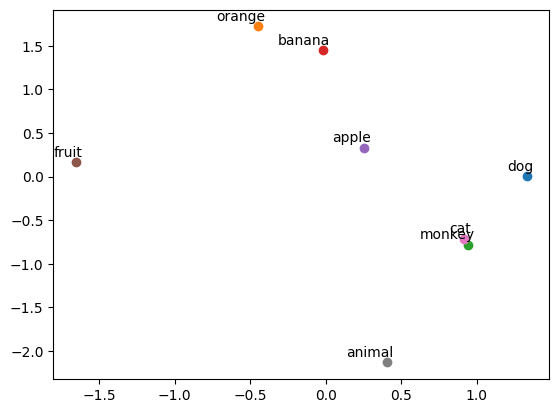

In [6]:
for i, label in enumerate(word_list):
    W, WT = model.parameters()
    x, y = W[0][i].item(), W[1][i].item()
    plt.scatter(x, y)
    plt.annotate(label, xy=(x, y), xytext=(5, 2), textcoords='offset points', ha='right', va='bottom')
plt.show()

## Notes

- This is a **from-scratch educational implementation** — for real-world use, prefer a mature library like `gensim.models.Word2Vec`, which supports negative sampling, subsampling of frequent words, and multi-threaded training on large corpora.
- `embedding_size = 2` was chosen only so the result could be plotted directly on an X/Y axis. Real-world embeddings typically use 100–300 dimensions.
- Since batches are sampled randomly each run, exact loss values and final cluster positions will vary slightly between runs — the *relative* clustering (fruits together, animals together) should still hold.